**Recipe recommendation with two towers**

Only `new_dataset_recommendation_df`, loaded from `input_stage2/recipe_user_ratings.csv`,
is used. Run `map_recipe_nutrients.ipynb` first when rebuilding that CSV: each rating
must retain its original `RAW_interactions.csv` **date**.

The **item tower** encodes separate ingredient, adjective, and verb semantic vectors,
per-recipe nutrition means, nutrition-cluster membership and cluster means, and summed
ingredient prices with missing-price uncertainty. The **user tower** combines a learned
**user-ID embedding** with a **GRU** (a recurrent neural network) that reads the user's
earlier ratings from oldest to newest. Attention over the GRU outputs gives the latest
ratings the most weight. The **cosine similarity** of the two tower vectors feeds an
ordinal head that gives probabilities for ratings 1–5. Training adds class-weighted
rating cross-entropy to **in-batch cross-entropy** (each liked row must pick its own
recipe out of the batch), and the expected rating ranks recommendations.

```text
Item tower:  recipe semantics + nutrition clusters + price → MLP → item vector
User tower:  user ID → ID embedding (row 0 = unknown user)
             earlier ratings, oldest → newest: recipe features + rating + days before target
               → GRU → last state + recency-weighted attention
             [ID embedding, GRU summary, history size] → MLP → user vector
Score:       cosine(user vector, item vector) → ordinal cut points → P(rating 1–5) → expected rating
Loss:        class-weighted rating CE + 0.5 × in-batch CE over cosine / 0.05 (other batch recipes = negatives)
```

This is supervised explicit-rating learning. Unrated recipes remain candidates but
never become zero-rating training labels. A user absent from training uses the
unknown-user ID row together with whatever history they have.

In [11]:
# Run once if these packages are missing, then restart the notebook kernel.
# %pip install torch transformers==5.17.0 numpy pandas scikit-learn joblib matplotlib
import json
import random
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch
from IPython.display import display

**Configuration**

`RECENCY_HALF_LIFE_DAYS = 180` gives a rating half its history weight after 180 days.
`USER_ID_DIM` sizes the user-ID embedding, and `USER_ID_DROPOUT` is the share of training
rows whose user ID is hidden so the unknown-user slot learns a default.
Each missing price contributes **±$2**, so three null ingredients contribute ±$6 around
the sum of known prices (lower bound clipped at zero). This is an uncertainty feature,
not an imputed ingredient cost. The item tower receives both the known sum and the
uncertainty. Nested fuzzy-price dictionaries are summed recursively.

Nutrition columns retain the input CSV's existing names, units, and values. Each column
is averaged separately per recipe; a list-valued cell is reduced to its nonmissing mean.
Duplicate interaction rows do not multiply a recipe's weight in clustering. Median
imputation, missing indicators, `log1p`, and scaling precede nutrition-only clustering.
Every recipe has a cluster; candidates are not restricted to the user's prior clusters.

`CLASS_WEIGHT`, the `IN_BATCH_*` settings, the stratified split, and the rating-5 thinning
limits are explained with training below.

In [12]:
RANDOM_STATE = 42
BERT_MODEL = "bert-base-uncased"
BERT_REVISION = "86b5e0934494bd15c9632b12f734a8a67f723594"
BERT_BATCH_SIZE = 64
BERT_MAX_LENGTH = 64
SEMANTIC_DIM_PER_FIELD = 128
NUTRITION_CLUSTERS = 32
MISSING_PRICE_ERROR_DOLLARS = 2.0
RECENCY_HALF_LIFE_DAYS = 180.0
MAX_HISTORY = 64
VALIDATION_FRACTION = 0.2
EMBEDDING_DIM = 64
HIDDEN_DIM = 128
USER_ID_DIM = 32
USER_ID_DROPOUT = 0.1
EPOCHS = 15
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 4
CLASS_WEIGHT = "balanced"  # scikit-learn style; None gives every rating weight 1.
IN_BATCH_WEIGHT = 0.5  # 0 turns the in-batch retrieval loss off.
IN_BATCH_TEMPERATURE = 0.05
IN_BATCH_MIN_RATING = 4
MAX_FIVE_STAR_TARGETS_PER_USER = 5
MAX_FIVE_TO_OTHER_RATIO = 1.0

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")
NOTEBOOK_DIR = next((p for p in (Path.cwd(), Path.cwd() / "DataMappingRecommendation")
                     if (p / "input_stage2/recipe_user_ratings.csv").is_file()), None)
if NOTEBOOK_DIR is None:
    raise FileNotFoundError("Run from DataMappingRecommendation or its project root; restore recipe_user_ratings.csv.")
DATA_PATH = NOTEBOOK_DIR / "input_stage2/recipe_user_ratings.csv"
ARTIFACT_DIR = NOTEBOOK_DIR / "model_artifacts/two_tower"
CACHE_DIR = NOTEBOOK_DIR / "output/two_tower_cache"
print(f"Device: {device}; recipe data: {DATA_PATH}")

Device: mps; recipe data: /Users/tung/Desktop/Học/Projects/ProjectSem1_2/DataMappingRecommendation/input_stage2/recipe_user_ratings.csv


**Self-contained model and data definitions**

The following two cells contain parsing, feature construction, both towers, chronological
history assembly, training, and prediction. No local model module is required.

In [13]:
"""Two-tower rating model: GRU user tower over strictly earlier dated ratings, cosine scoring."""
import copy
import math
import warnings
from decimal import Decimal, InvalidOperation

import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset

NUM_RATING_CLASSES = 5  # Ratings 1..5 are ordinal classes 0..4.


def canonical_id(value):
    """Normalize integer IDs loaded as numbers, strings, or CSV float strings."""
    if value is None or pd.isna(value):
        return None
    value = str(value).strip()
    if value.lower() in {"", "nan", "none", "null", "<na>"}:
        return None
    try:
        number = Decimal(value)
        if not number.is_finite():
            return None
        if number == number.to_integral_value():
            return str(int(number))
    except InvalidOperation:
        pass
    return value


def build_interactions(df, catalog):
    required = {"recipe_id", "user_id", "rating", "date"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Missing interaction columns {sorted(missing)}. Rerun map_recipe_nutrients.ipynb to export the original rating date.")
    catalog_ids = catalog["recipe_id"].map(canonical_id)
    if catalog_ids.isna().any() or catalog_ids.duplicated().any():
        raise ValueError("Catalog recipe_id values must be valid and unique after ID normalization.")
    frame = df.loc[:, ["recipe_id", "user_id", "rating", "date"]].copy()
    ratings = pd.to_numeric(frame["rating"], errors="coerce")
    malformed = frame["rating"].notna() & ratings.isna()
    invalid = ratings.notna() & ratings.ne(0) & ~ratings.between(1, 5)
    if malformed.any() or invalid.any():
        raise ValueError("Ratings must be numeric values from 1 to 5; use 0 or null for unlabeled rows.")
    frame["rating"] = ratings
    frame = frame.loc[ratings.between(1, 5)].copy()
    frame["user_id"] = frame["user_id"].map(canonical_id)
    frame["recipe_id"] = frame["recipe_id"].map(canonical_id)
    valid_ids = frame["user_id"].notna() & frame["recipe_id"].isin(set(catalog_ids))
    if (~valid_ids).any():
        warnings.warn(f"Excluded {(~valid_ids).sum():,} labeled rows with missing user IDs or recipes absent from the catalog.", stacklevel=2)
    frame = frame.loc[valid_ids].copy()
    frame["date"] = pd.to_datetime(frame["date"], format="mixed", errors="coerce", utc=True)
    if frame["date"].isna().any():
        raise ValueError("Labeled interactions contain missing/invalid dates. Rerun map_recipe_nutrients.ipynb and regenerate the mapped CSV with original dates; do not invent timestamps.")
    item_lookup = dict(zip(catalog_ids, range(len(catalog_ids))))
    frame["item_index"] = frame["recipe_id"].map(item_lookup).astype("int64")
    frame = frame.sort_values("date", kind="stable").drop_duplicates(["user_id", "recipe_id"], keep="last")
    return frame[["user_id", "item_index", "rating", "date"]].reset_index(drop=True)


def stratified_split(interactions, validation_fraction=0.2, seed=42):
    """Random holdout stratified on the rating, so both splits keep the same class shares."""
    if not 0 < validation_fraction < 1:
        raise ValueError("validation_fraction must lie between 0 and 1.")
    train, validation = train_test_split(interactions, test_size=validation_fraction,
                                         stratify=interactions["rating"], random_state=seed)
    order = ["user_id", "date"]
    return (train.sort_values(order, kind="stable").reset_index(drop=True),
            validation.sort_values(order, kind="stable").reset_index(drop=True))


def downsample_five_star_targets(targets, max_five_star=5, max_five_to_other_ratio=1.0, seed=42):
    """Randomly thin rating-5 targets of users who already have many of them.

    Each rating-5 row survives with probability min(1, limit / user's 5s), where
    limit = max(max_five_star, ratio * user's other ratings). Users under the limit are
    untouched; with ratio 1, a thinned user keeps about as many 5s as other ratings.
    """
    if max_five_star < 1 or not np.isfinite(max_five_to_other_ratio) or max_five_to_other_ratio < 0:
        raise ValueError("Use max_five_star >= 1 and a finite, nonnegative max_five_to_other_ratio.")
    five = targets["rating"].eq(5)
    per_user = five.groupby(targets["user_id"]).agg(["sum", "size"])
    limit = np.maximum(max_five_star, max_five_to_other_ratio * (per_user["size"] - per_user["sum"]))
    user_keep = (limit / per_user["sum"].clip(lower=1)).clip(upper=1.0)
    keep_probability = np.where(five, targets["user_id"].map(user_keep), 1.0)
    keep = np.random.default_rng(seed).random(len(targets)) < keep_probability
    return targets.loc[keep].reset_index(drop=True)


def rating_classes(ratings):
    """Map integer ratings 1..5 to ordinal class indices 0..4."""
    values = np.asarray(ratings, dtype=np.float64)
    classes = np.rint(values) - 1
    if not np.isin(classes, np.arange(NUM_RATING_CLASSES)).all() or not np.array_equal(values, classes + 1):
        raise ValueError("Rating classes require integer ratings from 1 to 5.")
    return classes.astype(np.int64)


def rating_class_weights(ratings, class_weight="balanced"):
    """Per-rating loss weights; "balanced" matches scikit-learn: n_samples / (n_classes * count)."""
    classes = rating_classes(ratings)
    if class_weight is None:
        return np.ones(NUM_RATING_CLASSES, dtype=np.float32)
    if class_weight != "balanced":
        raise ValueError('class_weight must be "balanced" or None.')
    if not len(classes):
        raise ValueError("Balanced class weights require at least one training rating.")
    present = np.unique(classes)
    weights = np.zeros(NUM_RATING_CLASSES, dtype=np.float32)
    weights[present] = compute_class_weight("balanced", classes=present, y=classes)
    # A rating absent from training cannot be fit; weigh its validation rows like the rarest rating.
    weights[weights == 0] = weights.max()
    return weights


class HistoryIndex:
    """Each user's ratings sorted by date: (dates in ns, item indices, rating classes 0..4)."""
    def __init__(self, history):
        frame = history.sort_values("date", kind="stable")
        dates = frame["date"].astype("int64").to_numpy()
        items = frame["item_index"].to_numpy(dtype=np.int64)
        classes = rating_classes(frame["rating"])
        self.users = {canonical_id(user): (dates[positions], items[positions], classes[positions])
                      for user, positions in frame.groupby("user_id", sort=False).indices.items()}


def _utc_day(value):
    stamp = pd.Timestamp(value)
    if pd.isna(stamp):
        raise ValueError("A valid as_of/reference_date is required.")
    return (stamp.tz_localize("UTC") if stamp.tzinfo is None else stamp.tz_convert("UTC")).floor("D")


def user_history(index, user_id, as_of, max_history=64, exclude_item=None):
    """Up to max_history ratings from UTC days strictly before as_of, oldest first.

    Returns item indices, rating classes 0..4, and each rating's age in days at as_of's day.
    The target recipe is excluded, so same-day ratings never reveal each other.
    """
    if max_history < 1:
        raise ValueError("max_history must be positive.")
    cutoff = int(as_of) if isinstance(as_of, (int, np.integer)) else _utc_day(as_of).value
    records = index.users.get(canonical_id(user_id))
    if records is None:
        return np.empty(0, np.int64), np.empty(0, np.int64), np.empty(0, np.float32)
    dates, items, classes = records
    end = np.searchsorted(dates, cutoff, side="left")
    # A user rates each recipe once, so one spare row covers the excluded target.
    selected = np.arange(max(0, end - max_history - 1), end)
    if exclude_item is not None:
        selected = selected[items[selected] != exclude_item]
    selected = selected[-max_history:]
    age_days = ((cutoff - dates[selected]) / (86400 * 1e9)).astype(np.float32)
    return items[selected], classes[selected], age_days


def pad_history(items, classes, age_days, max_history=64):
    """Right-pad one history to max_history steps; history_mask marks real ratings."""
    padded = {"history_items": np.zeros(max_history, np.int64), "history_ratings": np.zeros(max_history, np.int64),
              "history_age_days": np.zeros(max_history, np.float32), "history_mask": np.zeros(max_history, bool)}
    length = len(items)
    for key, values in [("history_items", items), ("history_ratings", classes), ("history_age_days", age_days)]:
        padded[key][:length] = values
    padded["history_mask"][:length] = True
    return {key: torch.from_numpy(value) for key, value in padded.items()}


def build_user_lookup(history):
    """User-ID vocabulary from training ratings: 1..n per user; 0 is the unknown user."""
    users = sorted(history["user_id"].map(canonical_id).dropna().unique())
    return {user: index for index, user in enumerate(users, start=1)}


def _feature_tensor(item_features, device):
    """Item features on the compute device, copied once so per-batch gathers stay there."""
    if torch.is_tensor(item_features):
        return item_features.to(device=device, dtype=torch.float32)
    return torch.as_tensor(np.asarray(item_features, dtype=np.float32)).to(device)


def user_inputs(batch, features, device):
    """User-tower tensors for one batch, trimmed to its longest history."""
    width = max(1, int(batch["history_mask"].sum(dim=1).max()))
    history_items = batch["history_items"][:, :width]
    return (batch["user_index"].to(device), features[history_items.to(features.device)].to(device),
            batch["history_ratings"][:, :width].to(device), batch["history_age_days"][:, :width].to(device),
            batch["history_mask"][:, :width].to(device))


class HistoryDataset(Dataset):
    """Rating targets, each with the user's strictly earlier ratings as a dated sequence."""
    def __init__(self, targets, history, user_lookup=None, max_history=64, half_life_days=180,
                 training=True, reference_date=None, weight_floor=0.1):
        self.targets = targets.reset_index(drop=True).copy()
        self.history_index = HistoryIndex(history)
        self.max_history, self.half_life_days = max_history, half_life_days
        if max_history < 1 or half_life_days <= 0 or not 0 < weight_floor <= 1:
            raise ValueError("Use max_history >= 1, half_life_days > 0, and 0 < weight_floor <= 1.")
        self.rating_classes = rating_classes(self.targets["rating"])
        lookup = user_lookup or {}
        self.user_indices = np.array([lookup.get(user, 0) for user in self.targets["user_id"]], dtype=np.int64)
        self.cutoffs = self.targets["date"].dt.floor("D").astype("int64").to_numpy()
        self.weights = np.ones(len(self.targets), dtype=np.float32)
        if training and len(self.targets):
            reference = history["date"].max() if reference_date is None else reference_date
            reference = _utc_day(reference)
            age = (reference - self.targets["date"].dt.floor("D")).dt.total_seconds().to_numpy() / 86400
            self.weights = np.maximum(weight_floor, np.exp2(-np.maximum(age, 0) / half_life_days)).astype(np.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, index):
        row = self.targets.iloc[index]
        sample = pad_history(*user_history(self.history_index, row.user_id, int(self.cutoffs[index]),
                                           self.max_history, exclude_item=row.item_index), self.max_history)
        sample.update({"user_index": int(self.user_indices[index]), "item_index": int(row.item_index),
                       "rating": torch.tensor(row.rating, dtype=torch.float32),
                       "rating_class": int(self.rating_classes[index]),
                       "sample_weight": torch.tensor(self.weights[index], dtype=torch.float32)})
        return sample


class TwoTowerModel(nn.Module):
    """Item MLP and GRU user tower, scored by cosine similarity through an ordinal head."""
    def __init__(self, feature_dim, num_users, embedding_dim=64, hidden_dim=128, user_id_dim=32,
                 half_life_days=180.0, user_id_dropout=0.1, rating_dim=16):
        super().__init__()
        if half_life_days <= 0 or not 0 <= user_id_dropout < 1:
            raise ValueError("Use half_life_days > 0 and 0 <= user_id_dropout < 1.")
        self.config = {"feature_dim": feature_dim, "num_users": num_users, "embedding_dim": embedding_dim,
                       "hidden_dim": hidden_dim, "user_id_dim": user_id_dim, "half_life_days": float(half_life_days),
                       "user_id_dropout": float(user_id_dropout), "rating_dim": rating_dim}
        self.item_tower = nn.Sequential(nn.Linear(feature_dim, hidden_dim), nn.LayerNorm(hidden_dim),
                                        nn.ReLU(), nn.Linear(hidden_dim, embedding_dim))
        # Row 0 is the unknown user; ID dropout trains it for users absent from training.
        self.user_embedding = nn.Embedding(num_users + 1, user_id_dim)
        self.history_projection = nn.Sequential(nn.Linear(feature_dim, hidden_dim), nn.ReLU())
        self.rating_embedding = nn.Embedding(NUM_RATING_CLASSES, rating_dim)
        self.history_rnn = nn.GRU(hidden_dim + rating_dim + 1, hidden_dim, batch_first=True)
        self.history_attention = nn.Linear(hidden_dim, 1)
        self.user_head = nn.Sequential(nn.Linear(2 * hidden_dim + 2 + user_id_dim, hidden_dim),
                                       nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, embedding_dim))
        self.logit_scale = nn.Parameter(torch.tensor(math.log(4.0)))
        # Four ordered cut points split one similarity into P(rating > k), k = 1..4.
        self.first_threshold = nn.Parameter(torch.tensor(-1.5))
        self.threshold_gaps = nn.Parameter(torch.full((NUM_RATING_CLASSES - 2,), math.log(math.e - 1)))

    def encode_items(self, features):
        return self.item_tower(features)

    def history_weights(self, outputs, history_age_days, history_mask):
        """Attention over history steps with a recency prior: one half-life older, half the weight."""
        scores = self.history_attention(outputs).squeeze(-1)
        scores = scores - history_age_days * (math.log(2) / self.config["half_life_days"])
        return torch.softmax(scores.masked_fill(~history_mask, -1e4), dim=1)

    def encode_users(self, user_index, history_features, history_ratings, history_age_days, history_mask):
        """GRU over past ratings (oldest first), recency-weighted attention, and a user-ID embedding."""
        if self.training and self.config["user_id_dropout"] > 0:
            hidden = torch.rand(user_index.shape, device=user_index.device) < self.config["user_id_dropout"]
            user_index = user_index.masked_fill(hidden, 0)
        lengths = history_mask.sum(dim=1)
        has_history = (lengths > 0).unsqueeze(-1).to(history_features.dtype)
        steps = torch.cat([self.history_projection(history_features), self.rating_embedding(history_ratings),
                           torch.log1p(history_age_days).unsqueeze(-1)], dim=-1)
        outputs, _ = self.history_rnn(steps)
        # Right padding comes after every real step, so the GRU state at length - 1 is the latest rating's.
        last = outputs[torch.arange(len(outputs), device=outputs.device), (lengths - 1).clamp_min(0)]
        pooled = (self.history_weights(outputs, history_age_days, history_mask).unsqueeze(-1) * outputs).sum(dim=1)
        summary = torch.cat([last * has_history, pooled * has_history, has_history,
                             torch.log1p(lengths.to(history_features.dtype)).unsqueeze(-1),
                             self.user_embedding(user_index)], dim=-1)
        return self.user_head(summary)

    def similarity(self, users, items):
        """Cosine similarity of tower vectors: their direction only, never their lengths."""
        return F.cosine_similarity(users, items, dim=-1)

    def threshold_steps(self):
        return F.softplus(self.threshold_gaps).clamp_min(1e-4)

    def thresholds(self):
        return torch.cat([self.first_threshold.view(1), self.first_threshold + self.threshold_steps().cumsum(0)])

    def exceedance_logits(self, similarity):
        """Logits of P(rating > k); one shared slope keeps scores monotone in similarity."""
        return self.logit_scale.exp().clamp(max=100) * similarity.unsqueeze(-1) - self.thresholds()

    def rating_log_probabilities(self, logits):
        """Stable log P(rating = 1..5) from cumulative (ordinal) logits."""
        above, below = F.logsigmoid(logits), F.logsigmoid(-logits)
        # sigmoid(a) - sigmoid(b) = sigmoid(a) * sigmoid(-b) * (1 - exp(b - a)); a - b is a threshold step.
        middle = above[..., :-1] + below[..., 1:] + torch.log(-torch.expm1(-self.threshold_steps()))
        return torch.cat([below[..., :1], middle, above[..., -1:]], dim=-1)

    @staticmethod
    def expected_rating(logits):
        return 1.0 + torch.sigmoid(logits).sum(dim=-1)

    def score_embeddings(self, users, items):
        return self.expected_rating(self.exceedance_logits(self.similarity(users, items)))

    def forward(self, user_index, history_features, history_ratings, history_age_days, history_mask, item_features):
        """Ordinal logits P(rating > k) for each (user, history, item) row."""
        users = self.encode_users(user_index, history_features, history_ratings, history_age_days, history_mask)
        return self.exceedance_logits(self.similarity(users, self.encode_items(item_features)))


def _rating_metrics(actual, predicted, predicted_class=None):
    """Overall errors plus per-rating averages, so each rare rating counts as much as rating 5."""
    actual, predicted = np.asarray(actual, dtype=np.float64), np.asarray(predicted, dtype=np.float64)
    names = ["rmse", "mae", "macro_mae"] + ([] if predicted_class is None else ["balanced_accuracy"])
    if not len(actual):
        return dict.fromkeys(names, float("nan"))
    classes, errors = rating_classes(actual), np.abs(actual - predicted)
    present = np.unique(classes)
    metrics = {"rmse": float(np.sqrt(np.mean(errors ** 2))), "mae": float(errors.mean()),
               "macro_mae": float(np.mean([errors[classes == c].mean() for c in present]))}
    if predicted_class is not None:
        hits = np.asarray(predicted_class) == classes
        metrics["balanced_accuracy"] = float(np.mean([hits[classes == c].mean() for c in present]))
    return metrics


def evaluate_baselines(train, validation):
    """All baseline estimates are fit on training ratings only."""
    global_mean = float(train["rating"].mean())
    predictions = {"global_mean": np.full(len(validation), global_mean)}
    for column, name in [("user_id", "user_mean"), ("item_index", "item_mean")]:
        means = train.groupby(column)["rating"].mean()
        predictions[name] = validation[column].map(means).fillna(global_mean).to_numpy()
    return pd.DataFrame([{"model": name, **_rating_metrics(validation["rating"], values)}
                         for name, values in predictions.items()])


def in_batch_losses(model, users, items, batch, log_q, temperature=0.05, min_rating=4.0):
    """In-batch sampled-softmax loss for each liked row, plus those rows' positions.

    A row rated at least min_rating must pick its own recipe among every recipe in the
    batch. Batches sample recipes by popularity, so each logit subtracts log q (logQ
    correction). The same recipe, or another row of the same user, is not a negative.
    """
    device = items.device
    rows = torch.nonzero(batch["rating"] >= min_rating).squeeze(1).to(device)
    if not len(rows):
        return items.new_zeros(0), rows
    item_index, user_index = batch["item_index"].to(device), batch["user_index"].to(device)
    logits = model.similarity(users[rows].unsqueeze(1), items.unsqueeze(0)) / temperature - log_q[item_index]
    same_item = item_index[rows].unsqueeze(1) == item_index.unsqueeze(0)
    same_user = (user_index[rows].unsqueeze(1) == user_index.unsqueeze(0)) & (user_index[rows] > 0).unsqueeze(1)
    own = F.one_hot(rows, len(item_index)).bool()
    logits = logits.masked_fill((same_item | same_user) & ~own, float("-inf"))
    return F.cross_entropy(logits, rows, reduction="none"), rows


@torch.no_grad()
def _prediction_pass(model, dataset, item_features, batch_size=512, device=None, in_batch=None):
    """Per-row ratings, expected ratings, and log P(rating = 1..5); mean in-batch CE if asked."""
    device = torch.device(device) if device is not None else next(model.parameters()).device
    features = _feature_tensor(item_features, device)
    actual, expected, log_probabilities, in_batch_total, in_batch_rows = [], [], [], 0.0, 0
    # Rows are sorted by user, so in-row-order batches would hold runs of one user whose
    # negatives in_batch_losses masks. A fixed shuffle matches training and every epoch.
    order = (torch.randperm(len(dataset), generator=torch.Generator().manual_seed(0)).tolist()
             if in_batch is not None else None)
    model.eval()
    for batch in DataLoader(dataset, batch_size=batch_size, sampler=order):
        users = model.encode_users(*user_inputs(batch, features, device))
        items = model.encode_items(features[batch["item_index"].to(device)])
        logits = model.exceedance_logits(model.similarity(users, items))
        actual.append(batch["rating"].numpy())
        expected.append(model.expected_rating(logits).cpu().numpy())
        log_probabilities.append(model.rating_log_probabilities(logits).cpu().numpy())
        if in_batch is not None:
            losses, _ = in_batch_losses(model, users, items, batch, **in_batch)
            in_batch_total, in_batch_rows = in_batch_total + float(losses.sum()), in_batch_rows + len(losses)
    in_batch_mean = in_batch_total / in_batch_rows if in_batch_rows else float("nan")
    if not actual:
        return (np.empty(0, np.float32), np.empty(0, np.float32),
                np.empty((0, NUM_RATING_CLASSES), np.float32), in_batch_mean)
    return np.concatenate(actual), np.concatenate(expected), np.concatenate(log_probabilities), in_batch_mean


def predict_ratings(model, dataset, item_features, batch_size=512, device=None):
    """Observed rating, expected rating, and log P(rating = 1..5) for every dataset row."""
    return _prediction_pass(model, dataset, item_features, batch_size, device)[:3]


def evaluate_two_tower(model, dataset, item_features, batch_size=512, device=None,
                       class_weights=None, in_batch=None):
    actual, expected, log_probabilities, in_batch_mean = _prediction_pass(
        model, dataset, item_features, batch_size, device, in_batch)
    metrics = _rating_metrics(actual, expected, log_probabilities.argmax(axis=1))
    if class_weights is not None:
        # Class-weighted mean cross-entropy: the training objective without recency weights.
        metrics["cross_entropy"] = float(F.nll_loss(
            torch.from_numpy(log_probabilities), torch.from_numpy(rating_classes(actual)),
            weight=torch.as_tensor(class_weights, dtype=torch.float32))) if len(actual) else float("nan")
    if in_batch is not None:
        metrics["in_batch_cross_entropy"] = in_batch_mean
    return metrics


def rating_class_report(actual, expected, log_probabilities):
    """Per-rating count, MAE, mean prediction, recall, and how often each rating is predicted."""
    classes, predicted = rating_classes(actual), np.asarray(log_probabilities).argmax(axis=1)
    frame = pd.DataFrame({"rating": classes + 1, "error": np.abs(np.asarray(actual) - np.asarray(expected)),
                          "expected": expected, "hit": predicted == classes})
    report = frame.groupby("rating").agg(count=("error", "size"), mae=("error", "mean"),
                                         mean_prediction=("expected", "mean"), recall=("hit", "mean"))
    report = report.reindex(pd.RangeIndex(1, NUM_RATING_CLASSES + 1, name="rating"))
    report["count"] = report["count"].fillna(0).astype(np.int64)
    report["predicted_count"] = np.bincount(predicted, minlength=NUM_RATING_CLASSES)
    return report


def train_two_tower(model, train_dataset, validation_dataset, item_features, epochs=15,
                    batch_size=256, learning_rate=1e-3, device=None, patience=4, class_weights=None,
                    in_batch_weight=0.5, in_batch_temperature=0.05, in_batch_min_rating=4.0):
    """Minimize rating cross-entropy + in_batch_weight x in-batch cross-entropy.

    The rating term is class-weighted, and recency sample weights scale both terms. The
    epoch with the lowest validation total loss (without recency weights) is kept.
    """
    if not len(train_dataset) or epochs < 1:
        raise ValueError("Training requires at least one labeled interaction and one epoch.")
    if in_batch_weight < 0 or in_batch_temperature <= 0:
        raise ValueError("Use in_batch_weight >= 0 and in_batch_temperature > 0.")
    if class_weights is None:
        class_weights = rating_class_weights(train_dataset.targets["rating"])
    class_weights = np.asarray(class_weights, dtype=np.float32)
    if class_weights.shape != (NUM_RATING_CLASSES,) or not np.isfinite(class_weights).all() or (class_weights < 0).any():
        raise ValueError("class_weights must hold one finite, nonnegative weight per rating 1-5.")
    device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    model.to(device)
    features = _feature_tensor(item_features, device)
    alpha = torch.as_tensor(class_weights, device=device)
    # A recipe's (add-one smoothed) share of training targets is its in-batch sampling rate q.
    counts = np.bincount(train_dataset.targets["item_index"].to_numpy(dtype=np.int64), minlength=len(features))
    log_q = torch.as_tensor(np.log((counts + 1) / (counts.sum() + len(counts))), dtype=torch.float32, device=device)
    in_batch = ({"log_q": log_q, "temperature": in_batch_temperature, "min_rating": in_batch_min_rating}
                if in_batch_weight > 0 else None)

    def total(cross_entropy, in_batch_cross_entropy):
        return cross_entropy + (in_batch_weight * in_batch_cross_entropy if math.isfinite(in_batch_cross_entropy) else 0.0)

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    # A fixed normalizer preserves recency and class weighting even for a one-row batch.
    normalizer = float(np.mean(train_dataset.weights * class_weights[train_dataset.rating_classes]))
    if normalizer <= 0:
        raise ValueError("Every training rating has zero class weight.")
    best_score, best_state, best_metrics, stale, records = float("inf"), None, None, 0, []
    for epoch in range(1, epochs + 1):
        model.train()
        weighted_loss, total_weight, in_batch_loss, in_batch_row_weight = 0.0, 0.0, 0.0, 0.0
        for batch in loader:
            optimizer.zero_grad(set_to_none=True)
            users = model.encode_users(*user_inputs(batch, features, device))
            items = model.encode_items(features[batch["item_index"].to(device)])
            logits = model.exceedance_logits(model.similarity(users, items))
            classes = batch["rating_class"].to(device)
            weights = batch["sample_weight"].to(device)
            losses = weights * F.nll_loss(model.rating_log_probabilities(logits), classes,
                                          weight=alpha, reduction="none")
            loss = losses.mean() / normalizer
            if in_batch is not None:
                retrieval, rows = in_batch_losses(model, users, items, batch, **in_batch)
                if len(rows):
                    row_weights = weights[rows]
                    loss = loss + in_batch_weight * (row_weights * retrieval).sum() / row_weights.sum()
                    in_batch_loss += float((row_weights * retrieval).sum().detach().cpu())
                    in_batch_row_weight += float(row_weights.sum().cpu())
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            weighted_loss += float(losses.sum().detach().cpu())
            total_weight += float((weights * alpha[classes]).sum().cpu())
        validation = evaluate_two_tower(model, validation_dataset, features, batch_size, device,
                                        class_weights, in_batch)
        train_loss = weighted_loss / total_weight
        train_in_batch = in_batch_loss / in_batch_row_weight if in_batch_row_weight else float("nan")
        validation_in_batch = validation.get("in_batch_cross_entropy", float("nan"))
        validation_total = total(validation["cross_entropy"], validation_in_batch)
        records.append({"epoch": epoch, "train_cross_entropy": train_loss, "train_in_batch_cross_entropy": train_in_batch,
                        "train_total_loss": total(train_loss, train_in_batch),
                        **{f"validation_{name}": value for name, value in validation.items()},
                        "validation_total_loss": validation_total})
        print(f"Epoch {epoch:02d}: train CE={train_loss:.4f}, in-batch={train_in_batch:.4f}; "
              f"validation CE={validation['cross_entropy']:.4f}, in-batch={validation_in_batch:.4f}, "
              f"total={validation_total:.4f}, macro MAE={validation['macro_mae']:.4f}, RMSE={validation['rmse']:.4f}")
        score = validation_total if len(validation_dataset) else total(train_loss, train_in_batch)
        if not math.isfinite(score):
            raise RuntimeError("Training produced non-finite loss; check item features and labels.")
        if score < best_score:
            best_score, best_state, best_metrics, stale = score, copy.deepcopy(model.state_dict()), validation, 0
        else:
            stale += 1
            if stale >= patience:
                break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(records), best_metrics


@torch.no_grad()
def encode_catalog(model, item_features, batch_size=1024, device=None):
    device = torch.device(device) if device is not None else next(model.parameters()).device
    model.eval()
    features = torch.as_tensor(np.asarray(item_features, dtype=np.float32))
    return torch.cat([model.encode_items(batch.to(device)).cpu()
                      for batch in features.split(batch_size)], dim=0)


@torch.no_grad()
def recommend_recipes(model, catalog, item_features, interactions, user_id, user_lookup=None, top_k=10,
                      as_of=None, max_history=64, item_embeddings=None):
    if top_k < 1:
        raise ValueError("top_k must be positive.")
    # An explicit cutoff prevents future ratings from affecting historical recommendations.
    now = pd.Timestamp.now(tz="UTC")
    cutoff = _utc_day(as_of) if as_of is not None else _utc_day(now)
    user_key = canonical_id(user_id)
    user_rows = interactions.loc[interactions["user_id"].map(canonical_id).eq(user_key)]
    observed = user_rows.loc[user_rows["date"] < cutoff]
    history = pad_history(*user_history(HistoryIndex(observed), user_key, cutoff.value, max_history), max_history)
    batch = {key: value.unsqueeze(0) for key, value in history.items()}
    batch["user_index"] = torch.tensor([(user_lookup or {}).get(user_key, 0)])
    device = next(model.parameters()).device
    model.eval()
    features = torch.as_tensor(np.asarray(item_features, dtype=np.float32))
    user_embedding = model.encode_users(*user_inputs(batch, features, device)).cpu()
    embeddings = encode_catalog(model, features) if item_embeddings is None else torch.as_tensor(item_embeddings).cpu()
    similarity = model.similarity(user_embedding, embeddings)
    scores = model.expected_rating(model.exceedance_logits(similarity.to(device))).cpu()
    # Serving "now" also hides recipes rated earlier today, which are not history yet.
    seen_rows = observed if as_of is not None else user_rows.loc[user_rows["date"] <= now]
    seen = seen_rows["item_index"].to_numpy(dtype=np.int64)
    scores[seen] = -torch.inf
    eligible = torch.isfinite(scores).sum().item()
    selected = torch.topk(scores, min(top_k, eligible)).indices.numpy()
    columns = [column for column in catalog.columns if column in {"recipe_id", "name"} or "price" in column or "cost" in column]
    result = catalog.iloc[selected][columns].copy()
    result["predicted_rating"] = scores[selected].numpy()
    return result.reset_index(drop=True)

In [14]:
# Content features are computed once per recipe; rating frequency never weights them.
import ast
import hashlib
import json
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, normalize
from transformers import AutoModel, AutoTokenizer

NUTRITION_COLUMNS = [
    'calories (g)', 'total fat (g)', 'sugar (g)', 'sodium (g)',
    'protein (g)', 'saturated fat (g)', 'carbohydrates (g)',
]
TEXT_FIELDS = ('ingredient_terms', 'adj_terms', 'verb_terms')
PRICE_FEATURE_COLUMNS = ['price_total_known', 'price_error_dollars',
                         'price_missing_fraction', 'price_all_missing']


# Cached: every caller shares the returned lists/dicts, so never mutate them.
@lru_cache(maxsize=100_000)
def parse_literal(text):
    text = text.strip()
    if text.lower() in {'', 'none', 'null', 'nan', '<na>'}:
        return None
    try:
        return json.loads(text)
    except (ValueError, TypeError):
        try:
            return ast.literal_eval(text)
        except (ValueError, SyntaxError):
            if text.startswith(('[', '{', '(')):
                raise ValueError(f'Malformed serialized feature: {text[:100]!r}')
            return text


def flatten_terms(value, nested=False):
    """Lower-cased terms from text, a nested list, or its serialized form.

    Only a top-level string or a list-like element such as '["a"]' is parsed; other strings
    inside a list are terms as written, so "2", "true" or "(optional)" stay text.
    """
    if isinstance(value, str):
        text = value.strip()
        if nested and not text.startswith('['):
            return [text.lower()] if text else []
        try:
            parsed = parse_literal(text)
        except ValueError:
            if not nested:
                raise
            return [text.lower()]
        if isinstance(parsed, str):
            return [parsed.strip().lower()] if parsed.strip() else []
        return flatten_terms(parsed, nested=True)
    if isinstance(value, (list, tuple, np.ndarray)):
        return [term for part in value for term in flatten_terms(part, nested=True)]
    if value is None or value is pd.NA or (np.isscalar(value) and pd.isna(value)):
        return []
    raise ValueError(f'Expected ingredient/adjective/verb text, got {value!r}')


def nutrition_mean(value):
    def numbers(part):
        if isinstance(part, str):
            part = parse_literal(part)
        if isinstance(part, (list, tuple, np.ndarray)):
            return [number for child in part for number in numbers(child)]
        if part is None or pd.isna(part):
            return []
        number = float(part)
        if not np.isfinite(number):
            return []
        if number < 0:
            raise ValueError('Nutrition values must be nonnegative.')
        return [number]
    values = numbers(value)
    return float(np.mean(values)) if values else np.nan


def summarize_price(value, ingredient_count, missing_price_error=2.0):
    """Each null leaf contributes +/- $2 uncertainty, never a fabricated price."""
    if not np.isfinite(missing_price_error) or missing_price_error < 0:
        raise ValueError('missing_price_error must be finite and nonnegative.')
    payload = parse_literal(value) if isinstance(value, str) else value
    if not isinstance(payload, (dict, list, tuple)) and pd.isna(payload):
        payload = None
    def leaves(node):
        if isinstance(node, dict):
            return [leaf for child in node.values() for leaf in leaves(child)] or [None]
        if isinstance(node, (list, tuple)):
            return [leaf for child in node for leaf in leaves(child)] or [None]
        if node is None or pd.isna(node):
            return [None]
        number = float(node)
        if not np.isfinite(number):
            return [None]
        if number < 0:
            raise ValueError('Ingredient prices must be nonnegative.')
        return [number]
    if payload is None or (isinstance(payload, (dict, list)) and not payload):
        values = [None] * max(1, ingredient_count)
    else:
        if not isinstance(payload, (dict, list)):
            raise ValueError('price_breakdown must be a JSON dictionary/list or null.')
        values = leaves(payload)
    known = [price for price in values if price is not None]
    missing = len(values) - len(known)
    total = float(sum(known))
    error = float(missing_price_error * missing)
    return {'price_total_known': total, 'price_missing_count': missing,
            'price_error_dollars': error, 'price_lower': max(0., total - error),
            'price_upper': total + error, 'price_missing_fraction': missing / len(values),
            'price_all_missing': int(not known)}


def build_recipe_catalog(frame, missing_price_error=2.0):
    required = {'recipe_id', 'ingredients', 'adj', 'verb', 'price_breakdown', *NUTRITION_COLUMNS}
    if missing := required - set(frame):
        raise ValueError(f'Recipe CSV is missing columns: {sorted(missing)}. Rerun the mapping notebook.')
    # Work only on content columns, avoiding a second copy of all interaction rows.
    text_column = next((c for c in ('product', 'products') if c in frame), 'ingredients')
    columns = list(dict.fromkeys(['recipe_id', 'name', 'ingredients', text_column,
                                  'adj', 'verb', 'price_breakdown', *NUTRITION_COLUMNS]))
    columns = [column for column in columns if column in frame]
    recipes = frame[columns].drop_duplicates().copy()
    recipes['recipe_id'] = recipes['recipe_id'].map(canonical_id)
    if recipes['recipe_id'].isna().any():
        raise ValueError('Recipe IDs cannot be missing.')
    # Text/prices should be invariant across repeated rating rows for a recipe.
    content_columns = list(dict.fromkeys(['ingredients', text_column, 'adj', 'verb', 'price_breakdown']))
    conflicts = recipes.groupby('recipe_id')[content_columns].nunique(dropna=False).gt(1).any(axis=1)
    if conflicts.any():
        raise ValueError(f'Conflicting content for recipe IDs: {conflicts[conflicts].index[:5].tolist()}')
    for column in NUTRITION_COLUMNS:
        recipes[column] = recipes[column].map(nutrition_mean)
    # Average each nutrient independently per recipe, never mix unlike nutrient units.
    nutrient_means = recipes.groupby('recipe_id', sort=False)[NUTRITION_COLUMNS].mean()
    catalog = recipes.drop_duplicates('recipe_id').set_index('recipe_id')
    catalog[NUTRITION_COLUMNS] = nutrient_means.reindex(catalog.index)
    catalog = catalog.reset_index()
    if 'name' not in catalog:
        catalog['name'] = catalog['recipe_id']
    catalog['ingredient_terms'] = [
        flatten_terms(entities) or flatten_terms(original)
        for entities, original in zip(catalog[text_column], catalog['ingredients'])]
    for column in ('adj', 'verb'):
        catalog[f'{column}_terms'] = catalog[column].map(flatten_terms)
    price_rows = [summarize_price(value, len(set(terms)), missing_price_error)
                  for value, terms in zip(catalog['price_breakdown'], catalog['ingredient_terms'])]
    return pd.concat([catalog, pd.DataFrame(price_rows)], axis=1)


def encode_semantic_fields(catalog, cache_dir, device, model_name='bert-base-uncased',
                           revision='86b5e0934494bd15c9632b12f734a8a67f723594',
                           batch_size=64, max_length=64, semantic_dim=128, seed=42):
    """Frozen phrase BERT -> shared SVD -> separate mean-pooled text fields."""
    if len(catalog) == 0:
        raise ValueError('No recipes to encode.')
    terms = sorted({term for column in TEXT_FIELDS for row in catalog[column] for term in row})
    if not terms:
        raise ValueError('No ingredient/adjective/verb text found in the recipe catalog.')
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    identity = {'model': model_name, 'revision': revision, 'max_length': max_length,
                'pooling': 'mean_without_padding_or_special_tokens', 'terms': terms}
    key = hashlib.sha256(json.dumps(identity, sort_keys=True).encode()).hexdigest()
    cache_path = cache_dir / f'bert_phrases_{key}.npy'
    if cache_path.is_file():
        vectors = np.load(cache_path, allow_pickle=False)
        if vectors.ndim != 2 or len(vectors) != len(terms) or not np.isfinite(vectors).all():
            raise ValueError(f'Invalid phrase cache: {cache_path}')
    else:
        tokenizer = AutoTokenizer.from_pretrained(model_name, revision=revision)
        encoder = AutoModel.from_pretrained(model_name, revision=revision).to(device).eval()
        encoder.requires_grad_(False)
        vectors = np.empty((len(terms), encoder.config.hidden_size), dtype=np.float32)
        with torch.inference_mode():
            for start in range(0, len(terms), batch_size):
                encoded = tokenizer(terms[start:start + batch_size], padding=True, truncation=True,
                                    max_length=max_length, return_special_tokens_mask=True, return_tensors='pt')
                special = encoded.pop('special_tokens_mask').to(device)
                encoded = {key: value.to(device) for key, value in encoded.items()}
                hidden = encoder(**encoded).last_hidden_state
                mask = (encoded['attention_mask'].bool() & ~special.bool()).unsqueeze(-1)
                pooled = (hidden * mask).sum(1) / mask.sum(1).clamp_min(1)
                vectors[start:start + batch_size] = torch.nn.functional.normalize(pooled, dim=-1).cpu().numpy()
                if start % (batch_size * 50) == 0:
                    print(f'BERT phrases: {min(start + batch_size, len(terms)):,}/{len(terms):,}')
        np.save(cache_path, vectors, allow_pickle=False)
        del encoder
    # Compact shared phrase space bounds full-catalog and history memory use.
    components = min(semantic_dim, vectors.shape[1], max(1, len(vectors) - 1))
    reducer = None
    if len(vectors) > 1 and components < vectors.shape[1]:
        reducer = TruncatedSVD(n_components=components, random_state=seed)
        phrase_vectors = normalize(reducer.fit_transform(vectors)).astype(np.float32)
    else:
        phrase_vectors = vectors.astype(np.float32, copy=False)
    lookup = {term: i for i, term in enumerate(terms)}
    fields = []
    present = np.zeros((len(catalog), len(TEXT_FIELDS)), dtype=np.float32)
    for field_id, column in enumerate(TEXT_FIELDS):
        pooled = np.zeros((len(catalog), phrase_vectors.shape[1]), dtype=np.float32)
        for row_id, row_terms in enumerate(catalog[column]):
            if row_terms:
                pooled[row_id] = phrase_vectors[[lookup[term] for term in row_terms]].mean(axis=0)
                present[row_id, field_id] = 1.
        fields.append(normalize(pooled))
    return np.concatenate([*fields, present], axis=1).astype(np.float32), {
        'model_name': model_name, 'revision': revision, 'max_length': max_length,
        'semantic_dim': phrase_vectors.shape[1], 'svd': reducer,
        'text_fields': TEXT_FIELDS, 'phrase_cache_key': key,
    }


def build_numeric_features(catalog, n_clusters=32, seed=42):
    raw = catalog[NUTRITION_COLUMNS].to_numpy(dtype=np.float64)
    missing = ~np.isfinite(raw)
    medians = catalog[NUTRITION_COLUMNS].median().fillna(0.).to_numpy(dtype=np.float64)
    filled = np.where(missing, medians, raw)
    nutrition_scaler = StandardScaler()
    scaled = nutrition_scaler.fit_transform(np.log1p(filled)).astype(np.float32)
    distinct = len(np.unique(scaled, axis=0))
    count = max(1, min(n_clusters, len(catalog), distinct))
    clusterer = MiniBatchKMeans(n_clusters=count, random_state=seed, n_init=10,
                               batch_size=max(256, count * 3))
    labels = clusterer.fit_predict(scaled)
    catalog['nutrition_cluster'] = labels
    one_hot = np.eye(count, dtype=np.float32)[labels]
    cluster_means = pd.DataFrame(filled, columns=NUTRITION_COLUMNS).groupby(labels).mean()
    cluster_means.index.name = 'nutrition_cluster'
    # Actual per-column means over one row per recipe, not k-means' approximate centers.
    mean_features = nutrition_scaler.transform(np.log1p(cluster_means.loc[labels].to_numpy())).astype(np.float32)
    prices = catalog[PRICE_FEATURE_COLUMNS].to_numpy(dtype=np.float64)
    prices[:, :2] = np.log1p(prices[:, :2])
    price_scaler = StandardScaler()
    price_features = price_scaler.fit_transform(prices).astype(np.float32)
    numeric = np.concatenate([scaled, missing.astype(np.float32), one_hot, mean_features, price_features], axis=1)
    if not np.isfinite(numeric).all():
        raise ValueError('Item features contain non-finite values.')
    return numeric, cluster_means, {'nutrition_columns': NUTRITION_COLUMNS,
        'nutrition_medians': medians, 'nutrition_scaler': nutrition_scaler,
        'nutrition_clusterer': clusterer, 'cluster_means': cluster_means,
        'price_scaler': price_scaler, 'price_feature_columns': PRICE_FEATURE_COLUMNS}

In [15]:
new_dataset_recommendation_df = pd.read_csv(
    DATA_PATH, dtype={"recipe_id": "string", "user_id": "string"}, low_memory=False
)
if "date" not in new_dataset_recommendation_df:
    raise ValueError("The CSV has no date column. Rerun map_recipe_nutrients.ipynb to export original interaction dates.")
item_catalog = build_recipe_catalog(
    new_dataset_recommendation_df, missing_price_error=MISSING_PRICE_ERROR_DOLLARS
)
observed_ratings = build_interactions(new_dataset_recommendation_df, item_catalog)
train_ratings, validation_ratings = stratified_split(
    observed_ratings, validation_fraction=VALIDATION_FRACTION, seed=RANDOM_STATE
)
# Thin only training targets; histories and validation keep every genuine rating.
train_targets = downsample_five_star_targets(
    train_ratings, max_five_star=MAX_FIVE_STAR_TARGETS_PER_USER,
    max_five_to_other_ratio=MAX_FIVE_TO_OTHER_RATIO, seed=RANDOM_STATE
)
training_class_weights = rating_class_weights(train_targets["rating"], class_weight=CLASS_WEIGHT)
thinned_users = train_ratings["user_id"].value_counts().sub(
    train_targets["user_id"].value_counts(), fill_value=0).gt(0).sum()
print(f"{len(new_dataset_recommendation_df):,} source rows; {len(item_catalog):,} distinct recipes")
print(f"{len(train_ratings):,} training ratings; {len(validation_ratings):,} validation ratings")
print(f"Rating-5 thinning removed {len(train_ratings) - len(train_targets):,} training targets "
      f"from {thinned_users:,} users; {len(train_targets):,} targets remain")
display(new_dataset_recommendation_df.head())
rating_levels = pd.RangeIndex(1, NUM_RATING_CLASSES + 1, name="rating")
rating_balance = pd.DataFrame({
    name: frame["rating"].astype(int).value_counts().reindex(rating_levels, fill_value=0)
    for name, frame in [("observed", observed_ratings), ("train_history", train_ratings),
                        ("train_targets", train_targets), ("validation", validation_ratings)]
})
rating_balance["class_weight"] = training_class_weights
display(rating_balance)

1,132,367 source rows; 231,637 distinct recipes
857,216 training ratings; 214,304 validation ratings
Rating-5 thinning removed 322,584 training targets from 11,256 users; 534,632 targets remain


,recipe_id,name,calories (g),total fat (g),sugar (g),sodium (g),protein (g),saturated fat (g),carbohydrates (g),ingredients,user_id,rating,date,product,adj,verb,price_breakdown
0,137739,arriba baked winter squash mexican style,103000.0,0.0,650.0,0.0,100.0,0.0,1200.0,"['winter squash', 'mexican seasoning', 'mixed ...",4470,5,2006-02-18,"[[""winter squash""], [""mexican seasoning""], [""m...","[[], [], [], [], [], [], []]","[[], [], [], [], [], [], []]","{""honey"": null, ""olive oil"": 19.9, ""mexican se..."
1,137739,arriba baked winter squash mexican style,103000.0,0.0,650.0,0.0,100.0,0.0,1200.0,"['winter squash', 'mexican seasoning', 'mixed ...",593927,5,2010-08-21,"[[""winter squash""], [""mexican seasoning""], [""m...","[[], [], [], [], [], [], []]","[[], [], [], [], [], [], []]","{""honey"": null, ""olive oil"": 19.9, ""mexican se..."
2,137739,arriba baked winter squash mexican style,103000.0,0.0,650.0,0.0,100.0,0.0,1200.0,"['winter squash', 'mexican seasoning', 'mixed ...",178427,5,2011-12-05,"[[""winter squash""], [""mexican seasoning""], [""m...","[[], [], [], [], [], [], []]","[[], [], [], [], [], [], []]","{""honey"": null, ""olive oil"": 19.9, ""mexican se..."
3,31490,a bit different breakfast pizza,346800.0,1170.0,0.0,40800.0,1100.0,700.0,300.0,"['prepared pizza crust', 'sausage patty', 'egg...",319943,4,2009-07-18,"[[""pizza""], [""sausage patty""], [""egg""], [""milk...","[[], [], [], [], [], []]","[[""prepared""], [], [], [], [], []]","{""sausage patty"": null, ""eggs"": 4.18, ""prepare..."
4,31490,a bit different breakfast pizza,346800.0,1170.0,0.0,40800.0,1100.0,700.0,300.0,"['prepared pizza crust', 'sausage patty', 'egg...",674022,5,2011-04-10,"[[""pizza""], [""sausage patty""], [""egg""], [""milk...","[[], [], [], [], [], []]","[[""prepared""], [], [], [], [], []]","{""sausage patty"": null, ""eggs"": 4.18, ""prepare..."


,observed,train_history,train_targets,validation,class_weight
rating,,,,,
1,12818,10254,10254,2564,10.427774
2,14123,11299,11299,2824,9.463350
3,40855,32684,32684,8171,3.271521
4,187360,149888,149888,37472,0.713375
5,816364,653091,330507,163273,0.323522


**Rating data overview**

These plots use every de-duplicated 1–5 rating (`observed_ratings`), before the
train/validation split and before rating-5 thinning. They show:

1. how many ratings each class 1–5 has;
2. the recipes with the highest and lowest **average** rating, counting only recipes with
   at least `MIN_RATINGS_FOR_AVERAGE` ratings (ties go to the recipe with more ratings);
   without that minimum, the top of the list would be recipes with one 5-star rating;
3. the most rated recipes, and how many recipes have 0, 1, 2, … ratings. The 0 bar is
   the recipes **without a rating**: they appear only in rows with rating 0 (a review
   without stars). The table lists the least rated recipes.

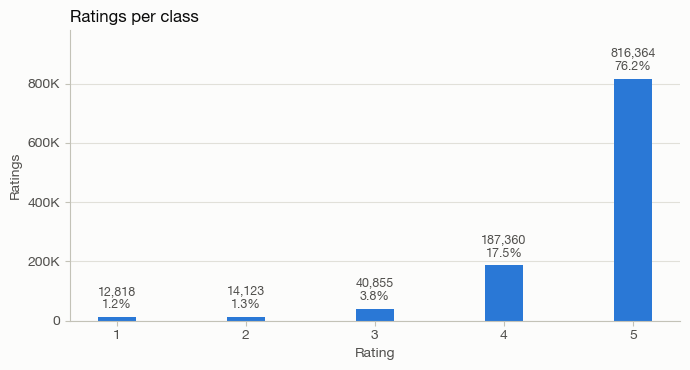

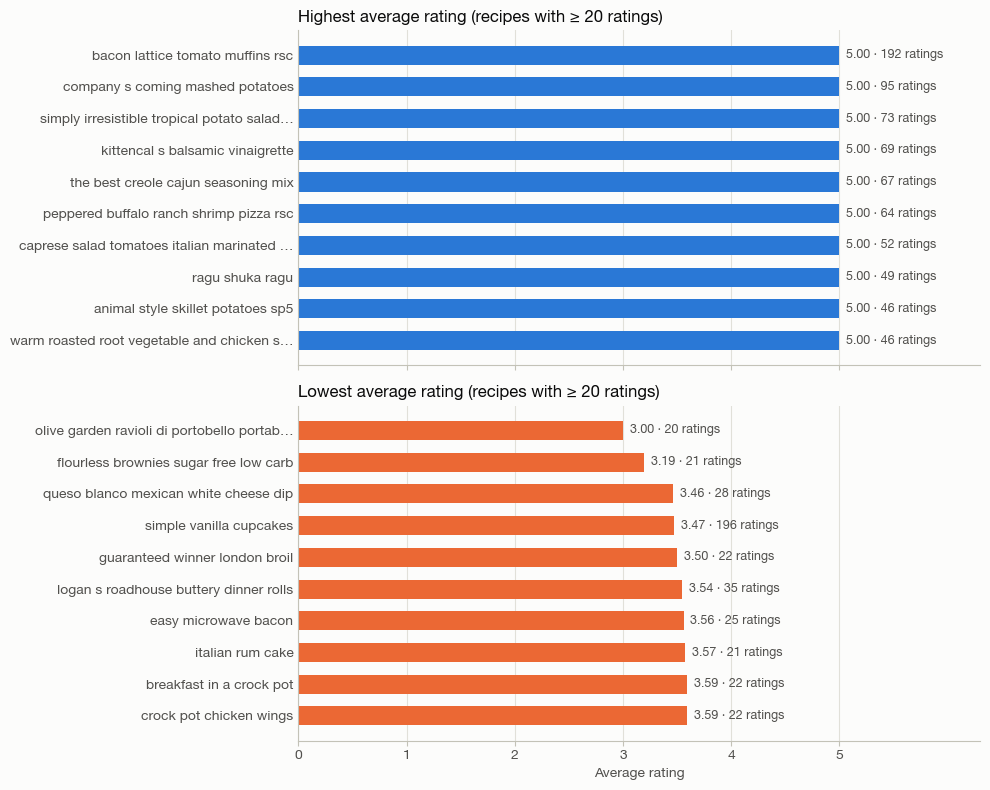

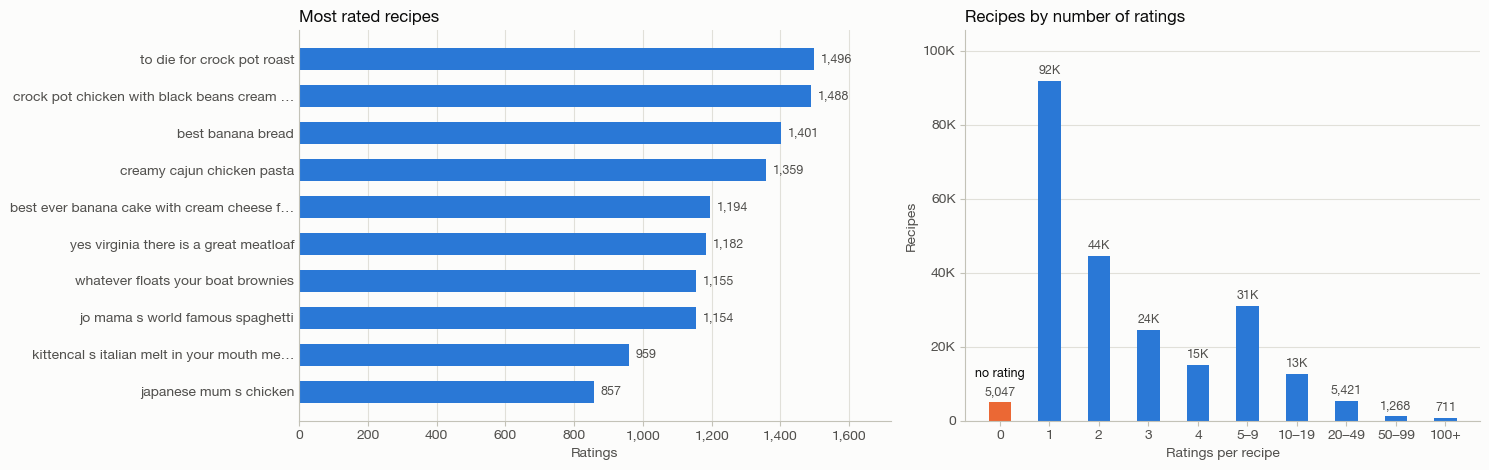

5,047 of 231,637 recipes (2.2%) have no rating; 91,698 have exactly one.


,recipe_id,name,rating_count,average_rating
least rated,,,,
0,164100,1 2 3 hash browns pie k,0,NaN
1,471666,1 2 3 swiss meringue buttercream,0,NaN
2,533190,1 minute breakfast sandwich,0,NaN
3,459738,1 point plus hg s faux fried pickles,0,NaN
4,472955,14 day pickles,0,NaN
5,525649,15 bean soup in the instant pot,0,NaN
6,246548,15 minute italian chicken rice with vegetables,0,NaN
7,531148,15 minute shrimp stir fry,0,NaN
8,282812,15 minutes oatmeal rice cooker,0,NaN


In [16]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

MIN_RATINGS_FOR_AVERAGE = 20
TOP_N = 10
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
VIZ_STYLE = {
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_2, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.titlelocation": "left", "axes.titlecolor": INK,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
}


def compact(value, _=None):
    return f"{value / 1e6:.1f}M" if value >= 1e6 else f"{value / 1e3:.0f}K" if value >= 1e4 else f"{value:,.0f}"


def short_name(name, width=42):
    name = " ".join(str(name).split())
    return name if len(name) <= width else name[:width - 1] + "…"


def ranked_bars(ax, frame, value, color, label, title):
    """Horizontal bars, first row on top, each labeled at its tip."""
    rows = frame.iloc[::-1]
    ax.barh(range(len(rows)), rows[value], height=0.6, color=color)
    ax.set_yticks(range(len(rows)), [short_name(name) for name in rows["name"]])
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="y", visible=False)
    for y, (_, row) in enumerate(rows.iterrows()):
        ax.annotate(label(row), (row[value], y), xytext=(5, 0), textcoords="offset points",
                    va="center", color=INK_2, fontsize=9)
    ax.set_title(title)


recipe_stats = item_catalog[["recipe_id", "name"]].copy()
recipe_stats["name"] = recipe_stats["name"].map(lambda name: " ".join(str(name).split()))
per_recipe = observed_ratings.groupby("item_index")["rating"].agg(["size", "mean"]).reindex(range(len(item_catalog)))
recipe_stats["rating_count"] = per_recipe["size"].fillna(0).astype(np.int64).to_numpy()
recipe_stats["average_rating"] = per_recipe["mean"].to_numpy()

# 1. Ratings per class.
class_counts = observed_ratings["rating"].astype(int).value_counts().reindex(
    range(1, NUM_RATING_CLASSES + 1), fill_value=0)
with plt.rc_context(VIZ_STYLE):
    fig, ax = plt.subplots(figsize=(7, 3.8))
    ax.bar(class_counts.index, class_counts, width=0.3, color=BLUE)
    for rating, count in class_counts.items():
        ax.annotate(f"{count:,}\n{count / class_counts.sum():.1%}", (rating, count), xytext=(0, 4),
                    textcoords="offset points", ha="center", va="bottom", color=INK_2, fontsize=9)
    ax.set(xticks=class_counts.index, xlabel="Rating", ylabel="Ratings", title="Ratings per class")
    ax.yaxis.set_major_formatter(FuncFormatter(compact))
    ax.grid(axis="x", visible=False)
    ax.margins(y=0.2)
    fig.tight_layout()
    plt.show()

# 2. Highest and lowest average rating among recipes with enough ratings.
rated_enough = recipe_stats[recipe_stats["rating_count"] >= MIN_RATINGS_FOR_AVERAGE]
best_rated = rated_enough.sort_values(["average_rating", "rating_count"], ascending=[False, False]).head(TOP_N)
worst_rated = rated_enough.sort_values(["average_rating", "rating_count"], ascending=[True, False]).head(TOP_N)
average_label = lambda row: f"{row.average_rating:.2f} · {row.rating_count:,} ratings"
with plt.rc_context(VIZ_STYLE):
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    ranked_bars(axes[0], best_rated, "average_rating", BLUE, average_label,
                f"Highest average rating (recipes with ≥ {MIN_RATINGS_FOR_AVERAGE} ratings)")
    ranked_bars(axes[1], worst_rated, "average_rating", ORANGE, average_label,
                f"Lowest average rating (recipes with ≥ {MIN_RATINGS_FOR_AVERAGE} ratings)")
    axes[1].set(xlim=(0, 6.3), xticks=range(6), xlabel="Average rating")
    fig.tight_layout()
    plt.show()

# 3. Most rated recipes, and recipes by number of ratings (0 = without a rating).
most_rated = recipe_stats.nlargest(TOP_N, "rating_count")
bucket_labels = ["0", "1", "2", "3", "4", "5–9", "10–19", "20–49", "50–99", "100+"]
buckets = pd.cut(recipe_stats["rating_count"], [0, 1, 2, 3, 4, 5, 10, 20, 50, 100, np.inf],
                 right=False, labels=bucket_labels).value_counts().reindex(bucket_labels)
with plt.rc_context(VIZ_STYLE):
    fig, (left, right) = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.15, 1]})
    ranked_bars(left, most_rated, "rating_count", BLUE, lambda row: f"{row.rating_count:,}", "Most rated recipes")
    left.set(xlim=(0, most_rated["rating_count"].max() * 1.15), xlabel="Ratings")
    left.xaxis.set_major_formatter(FuncFormatter(compact))
    right.bar(bucket_labels, buckets, width=0.45, color=[ORANGE] + [BLUE] * (len(bucket_labels) - 1))
    for x, count in enumerate(buckets):
        right.annotate(compact(count), (x, count), xytext=(0, 3), textcoords="offset points",
                       ha="center", va="bottom", color=INK_2, fontsize=9)
    right.annotate("no rating", (0, buckets.iloc[0]), xytext=(0, 16), textcoords="offset points",
                   ha="center", va="bottom", color=INK, fontsize=9)
    right.set(title="Recipes by number of ratings", xlabel="Ratings per recipe", ylabel="Recipes")
    right.yaxis.set_major_formatter(FuncFormatter(compact))
    right.grid(axis="x", visible=False)
    right.margins(y=0.15)
    fig.tight_layout()
    plt.show()

unrated = recipe_stats["rating_count"].eq(0)
print(f"{unrated.sum():,} of {len(recipe_stats):,} recipes ({unrated.mean():.1%}) have no rating; "
      f"{recipe_stats['rating_count'].eq(1).sum():,} have exactly one.")
least_rated = recipe_stats.sort_values(["rating_count", "name"], kind="stable").head(TOP_N)
display(least_rated.reset_index(drop=True).rename_axis("least rated"))

**Rating shares before and after rating-5 thinning**

Thinning changes training targets only, so this compares the training split before
thinning (`train_ratings`) with the thinned targets (`train_targets`). Validation and
user histories keep every rating. The plot reuses the style from the overview cell above.

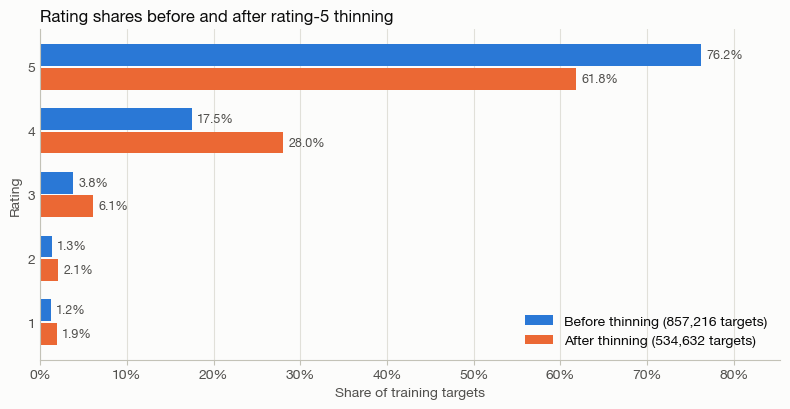

,before_count,before_percent,after_count,after_percent,change_points
rating,,,,,
1,10254,1.20,10254,1.92,0.72
2,11299,1.32,11299,2.11,0.80
3,32684,3.81,32684,6.11,2.30
4,149888,17.49,149888,28.04,10.55
5,653091,76.19,330507,61.82,-14.37


In [17]:
from matplotlib.ticker import PercentFormatter

counts = {when: frame["rating"].astype(int).value_counts().reindex(rating_levels, fill_value=0)
          for when, frame in [("before", train_ratings), ("after", train_targets)]}
thinning_shares = pd.DataFrame({
    "before_count": counts["before"], "before_percent": 100 * counts["before"] / counts["before"].sum(),
    "after_count": counts["after"], "after_percent": 100 * counts["after"] / counts["after"].sum(),
})
thinning_shares["change_points"] = thinning_shares["after_percent"] - thinning_shares["before_percent"]

bar_height, bar_gap = 0.34, 0.03
with plt.rc_context(VIZ_STYLE):
    fig, ax = plt.subplots(figsize=(8, 4.2))
    for when, color, direction in [("before", BLUE, 1), ("after", ORANGE, -1)]:
        positions = rating_levels + direction * (bar_height + bar_gap) / 2
        shares = thinning_shares[f"{when}_percent"]
        ax.barh(positions, shares, height=bar_height, color=color,
                label=f"{when.capitalize()} thinning ({counts[when].sum():,} targets)")
        for position, share in zip(positions, shares):
            ax.annotate(f"{share:.1f}%", (share, position), xytext=(4, 0), textcoords="offset points",
                        va="center", color=INK_2, fontsize=9)
    ax.set(yticks=rating_levels, xlabel="Share of training targets", ylabel="Rating",
           xlim=(0, thinning_shares[["before_percent", "after_percent"]].to_numpy().max() * 1.12),
           title="Rating shares before and after rating-5 thinning")
    ax.xaxis.set_major_formatter(PercentFormatter(100))
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="y", visible=False)
    ax.legend(frameon=False, loc="lower right")
    fig.tight_layout()
    plt.show()
display(thinning_shares.round(2))

**Frozen phrase semantics and nutrition clusters**

Each distinct phrase is encoded once by the pinned BERT checkpoint. Padding and special
tokens are excluded from mean pooling. A shared SVD compresses the frozen phrase vectors;
then each recipe separately mean-pools its ingredient, adjective, and verb phrases.
These three vectors and field-presence indicators remain separate item inputs.

Content preprocessing uses the complete recipe catalog, including unrated recipes, but
never reads user IDs, ratings, or dates. Validation therefore measures held-out ratings for
a known catalog, not a future-catalog cold-start scenario. Nutrition clusters use scaled
per-recipe nutrient means, and the displayed cluster means count each recipe once.

References: [BERT](https://huggingface.co/docs/transformers/model_doc/bert) and
[MiniBatchKMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MiniBatchKMeans.html).

In [18]:
semantic_features, semantic_preprocessing = encode_semantic_fields(
    item_catalog, CACHE_DIR, device, model_name=BERT_MODEL, revision=BERT_REVISION,
    batch_size=BERT_BATCH_SIZE, max_length=BERT_MAX_LENGTH,
    semantic_dim=SEMANTIC_DIM_PER_FIELD, seed=RANDOM_STATE
)
numeric_features, nutrition_cluster_means, numeric_preprocessing = build_numeric_features(
    item_catalog, n_clusters=NUTRITION_CLUSTERS, seed=RANDOM_STATE
)
item_features = np.concatenate([semantic_features, numeric_features], axis=1).astype(np.float32)
del semantic_features, numeric_features
assert np.isfinite(item_features).all()
print(f"Item feature matrix: {item_features.shape}; {item_features.nbytes / 2**20:.1f} MiB")
display(nutrition_cluster_means)
display(item_catalog[["recipe_id", "name", "nutrition_cluster", "price_total_known",
                      "price_missing_count", "price_error_dollars", "price_lower", "price_upper"]].head())

Item feature matrix: (231637, 444); 392.3 MiB


,calories (g),total fat (g),sugar (g),sodium (g),protein (g),saturated fat (g),carbohydrates (g)
nutrition_cluster,,,,,,,
0,2.152044e+06,6432.775895,2150.086373,184857.085908,5215.042190,2455.867384,6883.037672
1,1.794072e+05,14.454691,1610.445114,62501.720163,292.161731,1.017911,1725.305905
2,3.706258e+05,904.587372,525.764180,45218.741756,781.077594,310.692206,1653.948500
3,1.584559e+04,1.338235,64.779412,248089.411765,25.367647,0.411765,3.970588
4,5.626292e+05,15.244529,9907.322345,0.000000,170.008106,0.210754,5989.219130
5,1.614268e+05,396.399732,415.231388,29878.470825,257.679410,128.158283,694.406439
6,1.690281e+05,576.911218,138.818722,18340.564636,531.277860,224.621100,0.000000
7,6.959220e+05,1595.325660,5663.159326,28914.990031,532.517673,681.002961,4538.462933
8,1.269593e+06,4574.103774,0.000000,77238.896952,2912.264151,1493.759071,2365.602322


,recipe_id,name,nutrition_cluster,price_total_known,price_missing_count,price_error_dollars,price_lower,price_upper
0,137739,arriba baked winter squash mexican style,26,38.83,3,6.0,32.83,44.83
1,31490,a bit different breakfast pizza,17,25.95,2,4.0,21.95,29.95
2,112140,all in the kitchen chili,10,58.35,5,10.0,48.35,68.35
3,59389,alouette potatoes,10,32.77,6,12.0,20.77,44.77
4,44061,amish tomato ketchup for canning,29,30.35,4,8.0,22.35,38.35


**Stratified validation, history-only profiles, and recent ratings weighted more heavily**

Ratings 1–5 are observed labels; 0 and missing ratings are unrated. Missing or invalid
dates on observed ratings raise an error. Repeated user–recipe ratings keep their latest
event. Validation is a random 20% holdout **stratified on the rating** (scikit-learn
`train_test_split(..., stratify=y)`), so training and validation have the same share of
each rating 1–5. The holdout is random, not the newest ratings: the model can train on
ratings dated after some validation ratings. Validation therefore measures how well the
model fills in missing ratings, not how well it predicts future ones, and it may score
better than a time-based holdout would.

For every target, the user tower sees **only strictly earlier training ratings**, with the
target recipe excluded. Same-day events have no known order, so none can reveal another
same-day target. Validation ratings never enter training histories or validation histories.

**User tower.** The GRU reads up to 64 of the most recent earlier ratings, oldest first.
Each step sees the recipe's content features, a learned embedding of its rating, and
`log(1 + days before the target)`. Attention pools the GRU outputs. Each rating's score
starts with a recency prior of `−days × ln 2 / RECENCY_HALF_LIFE_DAYS`, so a rating 180 days
older gets half the weight before training adjusts it. The last GRU state, the pooled
state, the history size, and the user-ID embedding feed the user MLP. With no history,
the GRU summaries are zero and the ID embedding still applies. The ID embedding has one
row per training user plus row 0 for unknown users. In training, `USER_ID_DROPOUT = 0.1`
of rows use row 0 instead of the real ID, so row 0 learns a sensible default.

Training loss also gives more weight to recent targets, relative to the **training-only**
latest date; a 0.1 floor retains signal from older observations. Validation RMSE/MAE are
unweighted on the original 1–5 scale.

**Rating imbalance: thinning and class-weighted cross-entropy**

About 76% of observed ratings are 5, so an unweighted model can score well by predicting
almost 5 for everything. Two measures change **training targets only**; validation keeps
the real rating distribution, and user histories keep every training rating.

1. **Probabilistic rating-5 thinning.** Each rating-5 target is kept with probability
   `min(1, limit / user's 5s)`, where `limit = max(5, 1.0 × user's other ratings)`
   (`MAX_FIVE_STAR_TARGETS_PER_USER`, `MAX_FIVE_TO_OTHER_RATIO`). A thinned user keeps
   about as many 5s as other ratings, and at least 5. Users below the limit keep every
   row; users who give almost only 5s lose most of them. About half of training 5s go.
2. **Class-weighted cross-entropy**, `−α_y log p_y`. With `CLASS_WEIGHT = "balanced"` (as in
   scikit-learn), rating `r` has weight `α_r = n_targets / (5 × count_r)`, so each rating
   class carries equal total weight and a mistake on a rare rating costs more.

Cross-entropy needs class probabilities. Four ordered cut points on the cosine similarity give
`P(rating > k)` for `k = 1..4`, which yields probabilities for ratings 1–5. The predicted
rating is the expected value, `1 + Σ P(rating > k)`. That value rises with cosine
similarity, so recommendations are ranked by it. Recency weights still multiply the loss.
The epoch with the lowest validation total loss (below) is kept.

**In-batch cross-entropy (retrieval).** The rating loss scores each (user, recipe) pair on
its own. In-batch cross-entropy also teaches ranking: every row rated at least
`IN_BATCH_MIN_RATING = 4` must pick its own recipe out of all recipes in its batch, with
`cosine / IN_BATCH_TEMPERATURE` (0.05) as the logit. The batch's other recipes are the
negatives. Popular recipes appear in batches more often, so each logit subtracts `log q`,
the recipe's (add-one smoothed) share of training targets; without this logQ correction
the model learns to push popular recipes down. Another row with the same recipe, or
another row of the same user, is not a negative. The total loss is rating cross-entropy +
`IN_BATCH_WEIGHT` (0.5) × in-batch cross-entropy; recency weights scale both terms. Set
`IN_BATCH_WEIGHT = 0` to train on ratings only. Chance level for the in-batch loss is about
`ln(BATCH_SIZE)` ≈ 5.5.

Class-balanced predictions are not calibrated to the real 5-heavy distribution, so RMSE may
rise. Judge weak classes by `macro_mae`, which averages the per-rating MAEs, by
`balanced_accuracy`, and by per-rating recall in the report.

References: [sampling-bias-corrected in-batch softmax (logQ)](https://research.google/pubs/sampling-bias-corrected-neural-modeling-for-large-corpus-item-recommendations/),
[`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
and [`compute_class_weight`](https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html).

In [ ]:
# Thinned targets are supervised; every training rating still builds user histories.
user_lookup = build_user_lookup(train_ratings)
train_dataset = HistoryDataset(
    train_targets, train_ratings, user_lookup, max_history=MAX_HISTORY,
    half_life_days=RECENCY_HALF_LIFE_DAYS, training=True
)
validation_dataset = HistoryDataset(
    validation_ratings, train_ratings, user_lookup, max_history=MAX_HISTORY,
    half_life_days=RECENCY_HALF_LIFE_DAYS, training=False
)
recommendation_model = TwoTowerModel(
    feature_dim=item_features.shape[1], num_users=len(user_lookup), embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM, user_id_dim=USER_ID_DIM, half_life_days=RECENCY_HALF_LIFE_DAYS,
    user_id_dropout=USER_ID_DROPOUT
)
print(recommendation_model)
print(f"{len(user_lookup):,} training users; {(validation_dataset.user_indices > 0).mean():.1%} of "
      "validation ratings come from users seen in training")
recommendation_model, training_history, validation_metrics = train_two_tower(
    recommendation_model, train_dataset, validation_dataset, item_features,
    epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE,
    device=device, patience=EARLY_STOPPING_PATIENCE, class_weights=training_class_weights,
    in_batch_weight=IN_BATCH_WEIGHT, in_batch_temperature=IN_BATCH_TEMPERATURE,
    in_batch_min_rating=IN_BATCH_MIN_RATING
)
display(training_history)
display(pd.Series(validation_metrics, name="value").to_frame())
display(rating_class_report(*predict_ratings(recommendation_model, validation_dataset, item_features, device=device)))
baseline_metrics = evaluate_baselines(train_ratings, validation_ratings)
display(baseline_metrics)

**Recommend unseen recipes**

After validation is measured, serving may use all genuinely observed ratings. The example
uses a cutoff after the dataset's last interaction, appropriate for this historical data.
Set `as_of` explicitly to score from an earlier history; same-day/future ratings are excluded.
Pass `user_lookup` so a known user gets their ID embedding; unknown users use row 0.
Candidates with no ratings are still supported by item content. Predicted ratings are model
scores, not new observed labels. RMSE/MAE evaluate rating accuracy, not top-k retrieval quality.

In [ ]:
example_user_id = observed_ratings["user_id"].value_counts().index[0]
recommendations = recommend_recipes(
    recommendation_model, item_catalog, item_features, observed_ratings,
    user_id=example_user_id, user_lookup=user_lookup, top_k=20, max_history=MAX_HISTORY,
    as_of=observed_ratings["date"].max().floor("D") + pd.Timedelta(days=1)
)
print(f"Recipe recommendations for user {example_user_id}")
display(recommendations)

In [21]:
old_recipe_data = pd.read_csv("input_stage2/price_mapped_nutrients.csv")

**Save the model together with its serving features**

The artifact directory contains both towers, the frozen preprocessing objects, ordered
recipe catalog and features, precomputed item vectors, observed histories, the user-ID
vocabulary (`user_vocabulary.csv`), and configuration.
Keep them together: item index order must match across the catalog, arrays, and histories.
The reload example below uses the saved catalog directly and does not rerun BERT or clustering.

In [ ]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
model_config = recommendation_model.config
torch.save({"state_dict": {key: value.detach().cpu() for key, value in recommendation_model.state_dict().items()},
            "model_config": model_config}, ARTIFACT_DIR / "two_tower.pt")
np.save(ARTIFACT_DIR / "item_features.npy", item_features, allow_pickle=False)
item_vectors = encode_catalog(recommendation_model, item_features, device=device)
np.save(ARTIFACT_DIR / "item_vectors.npy", item_vectors, allow_pickle=False)
serving_columns = ["recipe_id", "name", "nutrition_cluster", *NUTRITION_COLUMNS,
                   "price_total_known", "price_missing_count", "price_error_dollars", "price_lower", "price_upper"]
item_catalog[serving_columns].to_csv(ARTIFACT_DIR / "catalog.csv", index=False)
observed_ratings.to_csv(ARTIFACT_DIR / "observed_ratings.csv", index=False)
pd.DataFrame({"user_id": list(user_lookup), "user_index": list(user_lookup.values())}).to_csv(
    ARTIFACT_DIR / "user_vocabulary.csv", index=False)
joblib.dump({"semantic": semantic_preprocessing, "numeric": numeric_preprocessing},
            ARTIFACT_DIR / "content_preprocessing.joblib")
config = {"format_version": "recipe_two_tower_v3", "model_config": model_config,
          "user_tower": "user_id_embedding_plus_gru_recency_attention", "similarity": "cosine",
          "rating_head": "ordinal_cumulative_logit", "loss": "class_weighted_cross_entropy",
          "retrieval_loss": "in_batch_sampled_softmax_logq", "in_batch_weight": IN_BATCH_WEIGHT,
          "in_batch_temperature": IN_BATCH_TEMPERATURE, "in_batch_min_rating": IN_BATCH_MIN_RATING,
          "class_weight": CLASS_WEIGHT, "rating_class_weights": training_class_weights.tolist(),
          "validation_split": "stratified_random", "max_five_star_targets_per_user": MAX_FIVE_STAR_TARGETS_PER_USER,
          "max_five_to_other_ratio": MAX_FIVE_TO_OTHER_RATIO,
          "bert_model": BERT_MODEL, "bert_revision": BERT_REVISION,
          "recency_half_life_days": RECENCY_HALF_LIFE_DAYS, "max_history": MAX_HISTORY,
          "missing_price_error_dollars": MISSING_PRICE_ERROR_DOLLARS,
          "random_state": RANDOM_STATE, "validation_fraction": VALIDATION_FRACTION,
          "source_csv": str(DATA_PATH), "rating_min": 1.0, "rating_max": 5.0}
(ARTIFACT_DIR / "config.json").write_text(json.dumps(config, indent=2) + "\n")
training_history.to_csv(ARTIFACT_DIR / "training_history.csv", index=False)
print(f"Saved two-tower model and serving data to {ARTIFACT_DIR.resolve()}")